# 21.08. Изменения объёмов камер на исторической контрастной КТ

## Цель и статус исследования

Задача — подготовить проверку точности TotalSegmentator при оценке межфазных изменений объёмов камер сердца. Сейчас представлены автоматические результаты и технический контроль. Независимые референсные маски отсутствуют; ошибка алгоритма, точность ударного объёма и фракции выброса ещё не установлены. По решению автора исследование продолжается без ожидания ручной разметки.

Используются те же задачи TotalSegmentator, что в [21.03](21.03_Вычитание_крови_и_объёмы_камер_RR.ipynb): `total` для целого сердца и `heartchambers_highres` для камер. Существующие результаты 21.03 не заменяются. Исторические серии образуют отдельную проверочную ветку.

## Данные и метод расчёта

Для первого прогона выбрана одна полная последовательность из 20 реконструированных фаз: 0–95% через 5%. Выбор сделан по полноте последовательности до получения автоматических масок. В текущем отчёте обработано **20 из 20 фаз**. Неполный набор позволяет оценить только изменения между представленными фазами; его размах не является размахом полного цикла.

Исходный формат — многокадровый Enhanced CT. В выбранной последовательности 99 пространственных срезов на фазу, размер 512 × 512, толщина реконструированного среза 5 мм и шаг между его положениями 2,5 мм. Эти величины имеют разный смысл: перекрытие срезов не увеличивает исходное пространственное разрешение до 2,5 мм. В DICOM отмечено введение контраста; это поле не устанавливает качество различимости каждой анатомической границы.

Положение срезов, ориентация, размеры пикселя и преобразование интенсивности читаются из функциональных групп DICOM. Координаты преобразуются из LPS в RAS; единицы NIfTI — миллиметры. Маски анализируются на сетке исходной преобразованной КТ, без сглаживания и удаления компонент. Объём равен числу включённых вокселей, умноженному на модуль определителя пространственной части affine-матрицы и делённому на 1000; результат выражен в миллилитрах.

Фазовые проценты не преобразуются в секунды. Фазы 0% и 50% не объявляются автоматически конечной диастолой и систолой. Кровь каждого желудочка и предсердия рассматривается отдельно; изменение объёма наружной маски сердца не подменяет ударный объём желудочка.

## Автоматические объёмы камер

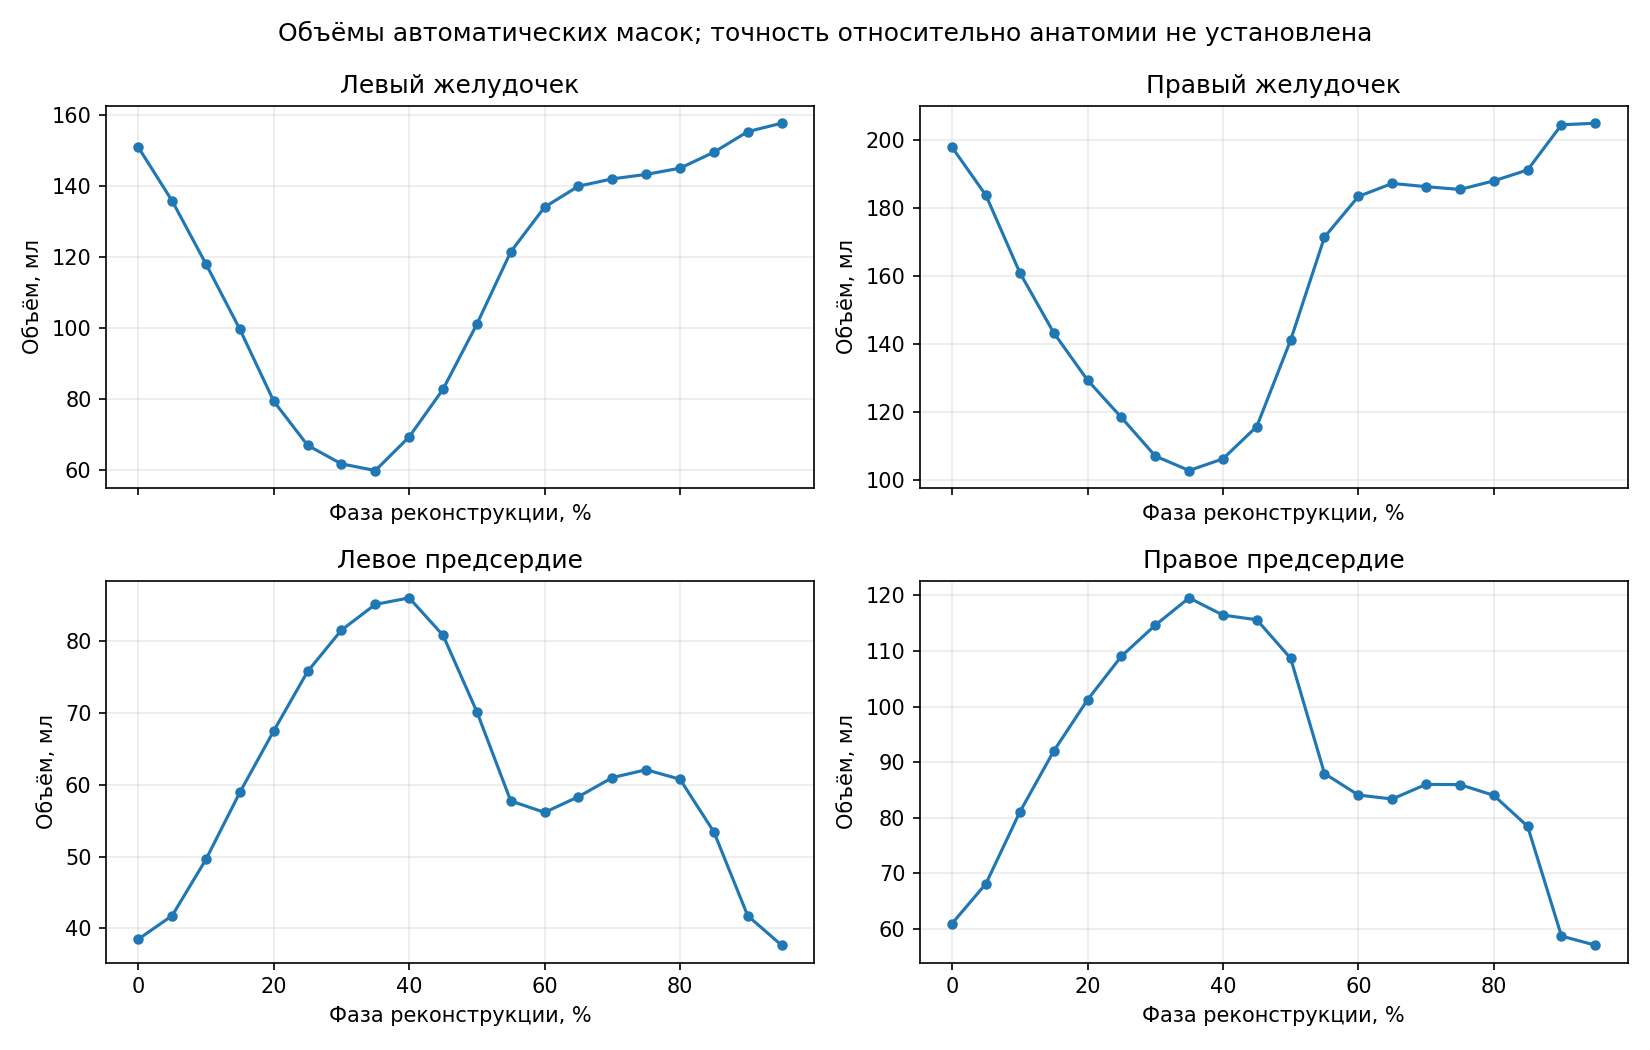

**Рисунок 1.** Точки соответствуют рассчитанным маскам. Линии соединяют соседние доступные фазы и не являются физиологической моделью или оценкой промежуточных состояний. Различие высот точек показывает изменение автоматического объёма; оно включает движение анатомических границ, особенности реконструкции и ошибки сегментации. Без референса эти составляющие не разделены.

## Численный результат и его трактовка

| Камера | Минимум, мл | Максимум, мл | Размах доступных фаз, мл |
|---|---:|---:|---:|
| Левый желудочек | 59.78 | 157.59 | 97.81 |
| Правый желудочек | 102.69 | 204.81 | 102.12 |
| Левое предсердие | 37.65 | 86.08 | 48.42 |
| Правое предсердие | 57.10 | 119.55 | 62.45 |

Таблица описывает доступные автоматические маски. Приведённый размах пока не назван ударным объёмом: для этого требуется обосновать конечные состояния и проверить границы камер. При частичном прогоне добавление фаз может увеличить найденный размах. Даже полная последовательность не устраняет ошибку сегментации.

## Технический контроль и ограничения

Совпадение размеров и affine-матриц масок с КТ проверено для каждого включённого результата. Пустые маски и касания границы изображения проверены отдельно; найдено записей с такими признаками: **45**. Отсутствие этих признаков не доказывает правильность клапанных и эндокардиальных границ. Анатомический визуальный просмотр в этом прогоне не выполнен.

В этой выборке один человек и одна последовательность. Фазы не являются независимыми участниками. Доверительные интервалы популяционной точности не рассчитываются. Полученные кривые нельзя переносить как нормальные физиологические законы на других людей. Будущая проверка на контрастных КТ отдельно от проверки применимости к нынешним слабоконтрастным сериям.

## Будущая проверка изменений объёма

Для каждой камеры и одинаковой пары фаз основной показатель — разность автоматического и референсного изменения объёма:

$$\varepsilon_{\Delta V}=[V_{TS}(t_2)-V_{TS}(t_1)]-[V_{ref}(t_2)-V_{ref}(t_1)] = e(t_2)-e(t_1).$$

Здесь $V_{TS}$ — объём автоматической маски, $V_{ref}$ — объём независимой референсной маски, $e(t)=V_{TS}(t)-V_{ref}(t)$ — ошибка объёма в конкретной фазе; все величины объёма выражены в миллилитрах. Постоянная по фазам составляющая ошибки сокращается при вычитании. Изменяющаяся составляющая непосредственно искажает оценку $\Delta V$. Поэтому одного Dice или средней ошибки абсолютного объёма недостаточно.

Ручные маски должны соответствовать тем же фазам и правилам выделения камер, включая клапанные плоскости, папиллярные мышцы и трабекулы. Чтобы не подгонять проверочный результат к алгоритму, независимую разметку следует создавать без использования его контуров как начального референса; доступ разметчика к автоматическим результатам фиксируется. Пилот включает 0, 25, 50 и 75%; после технической проверки требуется вся последовательность. Для поверхностных метрик допуск задаётся до сравнения с учётом разрешения и воспроизводимости разметки.

Последующий анализ включает подписанную и абсолютную ошибку $\Delta V$ в мл, ошибки объёмных кривых, ошибки отдельных объёмов и поверхностные метрики. Относительная ошибка изменения не интерпретируется при близком к нулю референсном изменении. УО и ФВ сравниваются только после независимого принятия конечных состояний. Протокол анатомического сравнения описан в [21.05](21.05_Валидация_анатомической_сегментации_сердца_4D_КТ.md).

## Вывод

Подготовлены автоматические пофазные объёмы и их изменения для последующего парного сравнения с ручными масками. Числа и графики показывают поведение алгоритма на выбранной контрастной последовательности. Пока они не позволяют утверждать, насколько точно TotalSegmentator измеряет изменения объёмов камер. Следующий содержательный результат — оценка ошибки этих изменений после независимой разметки; до её появления продолжаются автоматическая обработка, контроль геометрии и условные вычислительные эксперименты.